In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('./CSVs/EMNIST(DIGIT RE..)/train.csv')
# test=pd.read_csv("./CSVs/EMNIST(DIGIT RE..)/test.csv")

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


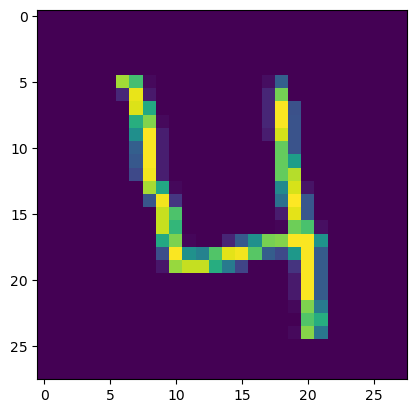

In [4]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [5]:
X=df.iloc[:,1:]
Y=df.iloc[:,0]

In [6]:
X.shape ,Y.shape

((42000, 784), (42000,))

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.1,random_state=32)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
knn = KNeighborsClassifier()

In [38]:
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
import time
st = time.time()
pred = knn.predict(x_test)
print(time.time() - st)

5.9221460819244385


In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy_score(y_test,pred)

0.9642857142857143

# Implementing PCA

In [10]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [11]:
x_tra_trf=sc.fit_transform(x_train)
x_tes_trf=sc.transform(x_test)

In [12]:
from sklearn.decomposition import PCA

In [15]:
import time
pca=PCA(n_components=2)

In [16]:
st = time.time()
x_tra_trf=pca.fit_transform(x_tra_trf)
x_tes_trf=pca.transform(x_tes_trf)
print(time.time() - st )

0.994220495223999


In [17]:
x_tra_trf.shape

(37800, 2)

In [48]:
knn1=KNeighborsClassifier()

In [49]:
knn1.fit(x_tra_trf,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
st = time.time()
pred = knn1.predict(x_tes_trf)
print(time.time() - st )

3.136664390563965


In [51]:
accuracy_score(pred,y_test)

0.935952380952381

In [ ]:
st = time.time()
for i in range(1,785):
    pca=PCA(n_components=i)
    x_tra_trf1=pca.fit_transform(x_tra_trf)
    x_tes_trf1=pca.transform(x_tes_trf)
    kn=KNeighborsClassifier()
    kn.fit(x_tra_trf1,y_train)
    pr=kn.predict(x_tes_trf1)
    print(accuracy_score(pr,y_test))

print(time.time() - st )

# Visulizing Data


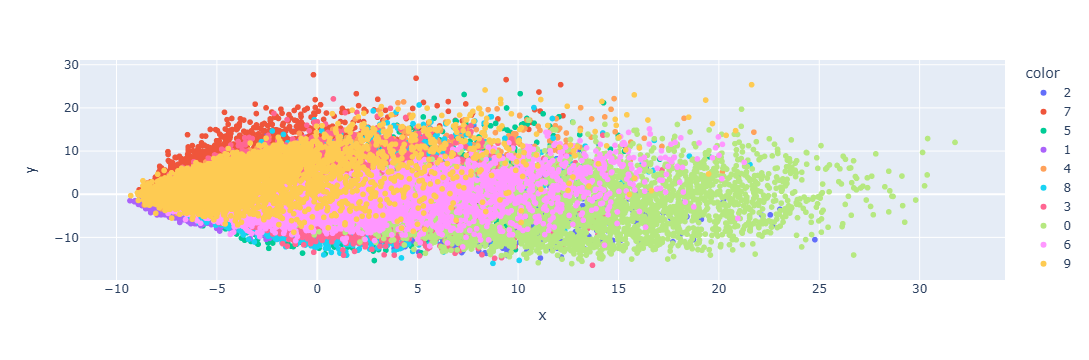

In [24]:
import plotly.express as px
y_tr_trf = y_train.astype(str)

fig = px.scatter(x=x_tra_trf[:,0],
                 y=x_tra_trf[:,1],
                color=y_tr_trf)
fig.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6224\2317624516.py:5: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



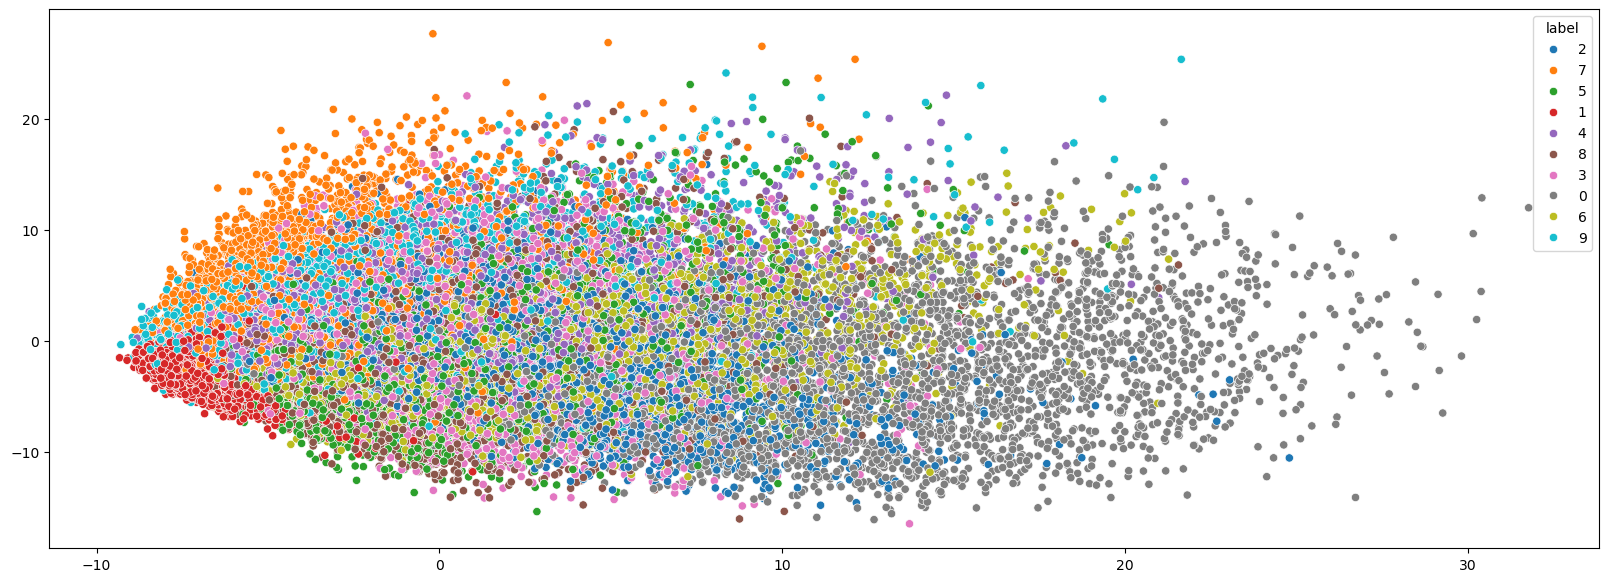

In [28]:
figu = plt.figure(figsize=(20,7))
sns.scatterplot(x=x_tra_trf[:,0],
                y=x_tra_trf[:,1],
                hue=y_tr_trf)
figu.show()

In [29]:
pca = PCA(n_components=3)

In [30]:
x_tra_trf = pca.fit_transform(x_train)
x_tes_trf = pca.transform(x_test)

In [31]:
x_tra_trf.shape

(37800, 3)

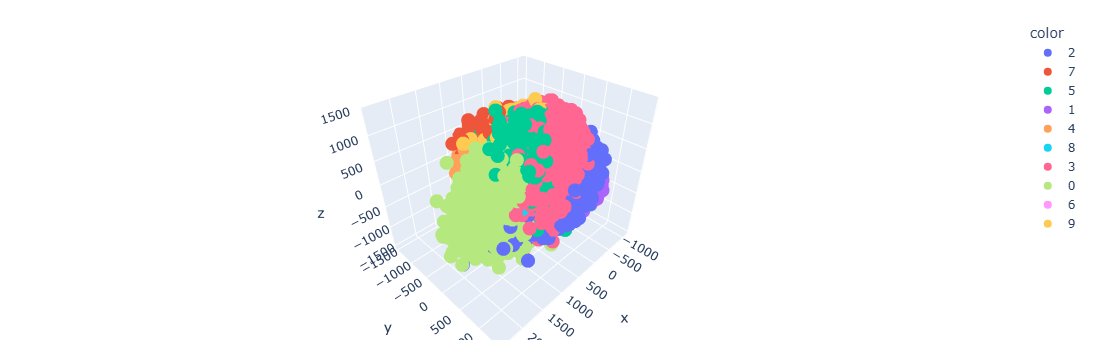

In [33]:
fig = px.scatter_3d( x=x_tra_trf[:,0],
                     y=x_tra_trf[:,1],
                     z=x_tra_trf[:,2],
                     color=y_tr_trf)
fig.update_layout(
    margin=dict(l=20,r=20,t=20,b=20)
)

fig.show()

In [34]:
pca.explained_variance_

array([335146.80936559, 246254.74845139, 210982.29546682])

In [37]:
pca.components_.shape

(3, 784)

In [38]:
pca = PCA(n_components=None)
x_tra_trf = pca.fit_transform(x_train)
x_tes_trf = pca.transform(x_test)

In [40]:
pca.explained_variance_.shape

(784,)

In [41]:
pca.components_.shape

(784, 784)

In [43]:
np.cumsum(pca.explained_variance_ratio_)

array([0.0975233 , 0.16918019, 0.23057326, 0.28441209, 0.33327922,
       0.37624628, 0.40903028, 0.43797909, 0.46567073, 0.48912179,
       0.51024564, 0.53085638, 0.54792026, 0.56478691, 0.58062396,
       0.59547677, 0.60861092, 0.62146055, 0.63332774, 0.64484267,
       0.65559829, 0.66572859, 0.67537814, 0.68450079, 0.69339581,
       0.70176686, 0.70991302, 0.71768747, 0.72511426, 0.73198813,
       0.73854576, 0.74494387, 0.75093623, 0.75679743, 0.76242259,
       0.76784019, 0.7729213 , 0.7778137 , 0.78259046, 0.78724567,
       0.79176247, 0.79620867, 0.80039421, 0.80437684, 0.80823354,
       0.81198506, 0.81559993, 0.81907946, 0.82245567, 0.82565762,
       0.82881251, 0.83191019, 0.83484695, 0.83771281, 0.84052483,
       0.84321523, 0.84586592, 0.84842806, 0.85095988, 0.85341226,
       0.85580739, 0.85819676, 0.86046517, 0.86267368, 0.86481228,
       0.86687229, 0.86889756, 0.87085735, 0.87279291, 0.87467847,
       0.87654426, 0.87835908, 0.8801219 , 0.88185032, 0.88350

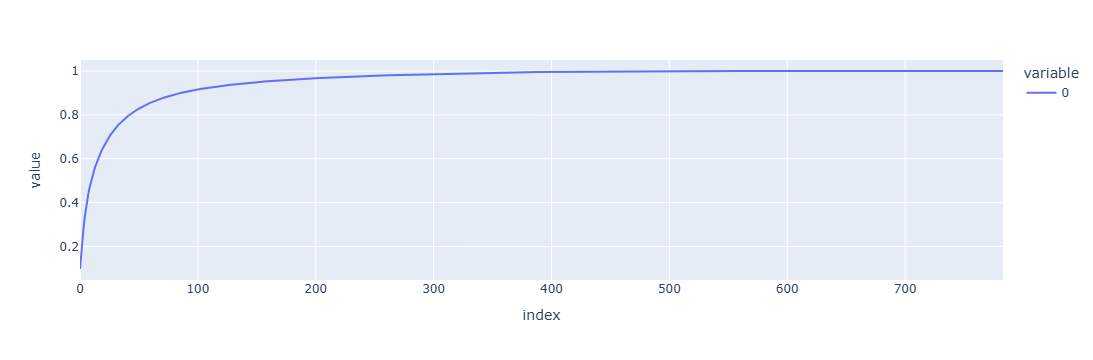

In [45]:
px.line(np.cumsum(pca.explained_variance_ratio_))